In [1]:
# Reproducibility: global seed setup
SEED = 42

import os
import random

# Set hash seed (effective on interpreter start; set early)
os.environ["PYTHONHASHSEED"] = str(SEED)

# Python's built-in RNG
random.seed(SEED)

# NumPy RNGs
try:
    import numpy as np
    np.random.seed(SEED)
    # Optional generator for new-style NumPy randomness
    RNG = np.random.default_rng(SEED)
except Exception:
    pass




print(f"Global seed set to {SEED} (random, numpy, optional torch/tf)")


Global seed set to 42 (random, numpy, optional torch/tf)


In [2]:
import pandas as pd
import numpy as np
from pathlib import Path

# Display options (optional but useful)
pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 140)

# Load dataset (case-safe for macOS/Linux)
DATA_DIR = Path('.')

def read_csv_case_safe(filename: str) -> pd.DataFrame:
    path = DATA_DIR / filename
    if path.exists():
        return pd.read_csv(path)
    # try common alternative casing
    alt = {
        'train.csv': 'Train.csv',
        'test.csv': 'Test.csv',
        'variabledefinitions.csv': 'VariableDefinitions.csv',
        'samplesubmission.csv': 'SampleSubmission.csv',
    }.get(filename.lower())
    if alt is not None and (DATA_DIR / alt).exists():
        return pd.read_csv(DATA_DIR / alt)
    # last resort: case-insensitive search
    candidates = list(DATA_DIR.glob(filename)) + list(DATA_DIR.glob(filename.lower()))
    if candidates:
        return pd.read_csv(candidates[0])
    raise FileNotFoundError(f"Could not find {filename} in {DATA_DIR.resolve()}")

train_dataset = read_csv_case_safe('Train.csv')
test_dataset = read_csv_case_safe('Test.csv')

In [4]:
train_dataset.head()

,ID,country,owner_age,attitude_stable_business_environment,attitude_worried_shutdown,compliance_income_tax,perception_insurance_doesnt_cover_losses,perception_cannot_afford_insurance,personal_income,business_expenses,business_turnover,business_age_years,motor_vehicle_insurance,has_mobile_money,current_problem_cash_flow,has_cellphone,owner_sex,offers_credit_to_customers,attitude_satisfied_with_achievement,has_credit_card,keeps_financial_records,perception_insurance_companies_dont_insure_businesses_like_yours,perception_insurance_important,has_insurance,covid_essential_service,attitude_more_successful_next_year,problem_sourcing_money,marketing_word_of_mouth,has_loan_account,has_internet_banking,has_debit_card,future_risk_theft_stock,business_age_months,medical_insurance,funeral_insurance,motivation_make_more_money,uses_friends_family_savings,uses_informal_lender,Target
0,ID_3CFL0U,eswatini,63.0,Yes,No,No,No,Yes,3000.0,6000.0,7000.0,14.0,Never had,Have now,Yes,Yes,Male,"Yes, sometimes",No,Never had,"Yes, always",Yes,Yes,No,Yes,Yes,Yes,Yes,Never had,Never had,Never had,NaN,6.0,Never had,Used to have but don’t have now,NaN,Never had,Never had,Low
1,ID_XWI7G3,zimbabwe,39.0,No,Yes,Yes,No,Yes,NaN,NaN,NaN,15.0,Have now,Have now,NaN,Yes,Male,"Yes, sometimes",Yes,Never had,"Yes, always",No,Yes,Yes,Yes,NaN,NaN,NaN,NaN,NaN,NaN,No,3.0,Never had,Never had,NaN,NaN,NaN,Medium
2,ID_TY93LV,malawi,34.0,Don’t know or N/A,No,No,Don't know,Yes,30000.0,6000.0,13000.0,5.0,NaN,Never had,Yes,Yes,Male,"Yes, sometimes",Yes,Never had,No,Don?t know / doesn?t apply,Yes,No,NaN,Yes,Yes,No,Never had,Never had,Never had,Yes,NaN,NaN,NaN,Yes,NaN,NaN,Low
3,ID_9OP2C8,malawi,28.0,Yes,No,No,No,No,180000.0,60000.0,30000.0,1.0,NaN,Have now,No,Yes,Female,"Yes, sometimes",No,Never had,No,No,Yes,No,NaN,Yes,No,No,Never had,Never had,Never had,No,NaN,NaN,NaN,Yes,Never had,Have now,Low
4,ID_13REYS,zimbabwe,43.0,Yes,No,No,Yes,Yes,50.0,2400.0,1800.0,3.0,Never had,NaN,NaN,No,Female,"Yes, sometimes",Yes,Never had,No,Yes,Yes,No,No,NaN,NaN,NaN,NaN,NaN,NaN,No,0.0,Never had,Never had,Yes,NaN,NaN,Low


### Data Analysis

In [5]:
# Basic dataset overview
print('Train shape:', train_dataset.shape)
print('Test shape :', test_dataset.shape)

print('\nTrain columns:', len(train_dataset.columns))
print('Test columns :', len(test_dataset.columns))

# Check target presence
target_col = 'Target'
print('\nTarget in train?', target_col in train_dataset.columns)
print('Target in test? ', target_col in test_dataset.columns)

Train shape: (9618, 39)
Test shape : (2405, 38)

Train columns: 39
Test columns : 38

Target in train? True
Target in test?  False


In [6]:
# Schema / types
display(train_dataset.dtypes.to_frame('dtype').head(50))

# Quick check: columns mismatch between train and test (excluding Target)
train_features = [c for c in train_dataset.columns if c != 'Target']
test_features = list(test_dataset.columns)

missing_in_test = sorted(set(train_features) - set(test_features))
extra_in_test = sorted(set(test_features) - set(train_features))

print('Missing in test (should be empty):', missing_in_test)
print('Extra in test (should be empty):', extra_in_test)

,dtype
ID,object
country,object
owner_age,float64
attitude_stable_business_environment,object
attitude_worried_shutdown,object
compliance_income_tax,object
perception_insurance_doesnt_cover_losses,object
perception_cannot_afford_insurance,object
personal_income,float64
business_expenses,float64


Missing in test (should be empty): []
Extra in test (should be empty): []


In [7]:
# Missing values overview (train + test)
def missing_report(df: pd.DataFrame, name: str, top_n: int = 25) -> pd.DataFrame:
    miss = df.isna().mean().sort_values(ascending=False)
    out = pd.DataFrame({
        'missing_rate': miss,
        'missing_count': df.isna().sum(),
        'dtype': df.dtypes.astype(str),
    })
    out.index.name = 'feature'
    print(f"\nTop missing features in {name} (top {top_n}):")
    return out.head(top_n)

display(missing_report(train_dataset, 'train', top_n=25))
display(missing_report(test_dataset, 'test', top_n=25))


Top missing features in train (top 25):


,missing_rate,missing_count,dtype
feature,,,
ID,0.000000,0,object
Target,0.000000,0,object
attitude_more_successful_next_year,0.271574,2612,object
attitude_satisfied_with_achievement,0.202329,1946,object
attitude_stable_business_environment,0.000208,2,object
attitude_worried_shutdown,0.000208,2,object
business_age_months,0.427428,4111,float64
business_age_years,0.026201,252,float64
business_expenses,0.023810,229,float64



Top missing features in test (top 25):


,missing_rate,missing_count,dtype
feature,,,
ID,0.000000,0,object
attitude_more_successful_next_year,0.271518,653,object
attitude_satisfied_with_achievement,0.202079,486,object
attitude_stable_business_environment,0.000000,0,object
attitude_worried_shutdown,0.000000,0,object
business_age_months,0.429522,1033,float64
business_age_years,0.024532,59,float64
business_expenses,0.029106,70,float64
business_turnover,0.029106,70,float64


In [8]:
# Duplicates & basic ID checks
id_col = 'ID'
print('ID in train?', id_col in train_dataset.columns)
print('ID in test? ', id_col in test_dataset.columns)

if id_col in train_dataset.columns:
    print('Train duplicate IDs:', train_dataset[id_col].duplicated().sum())
if id_col in test_dataset.columns:
    print('Test duplicate IDs :', test_dataset[id_col].duplicated().sum())

# Duplicate rows (excluding Target)
train_dupe_rows = train_dataset.drop(columns=['Target'], errors='ignore').duplicated().sum()
test_dupe_rows = test_dataset.duplicated().sum()
print('Train duplicate rows (features-only):', train_dupe_rows)
print('Test duplicate rows:', test_dupe_rows)

ID in train? True
ID in test?  True
Train duplicate IDs: 0
Test duplicate IDs : 0
Train duplicate rows (features-only): 0
Test duplicate rows: 0


In [9]:
# Target distribution (class balance)
if 'Target' in train_dataset.columns:
    target_counts = train_dataset['Target'].value_counts(dropna=False)
    target_rates = train_dataset['Target'].value_counts(normalize=True, dropna=False).round(4)
    display(pd.DataFrame({'count': target_counts, 'rate': target_rates}))
else:
    print('No Target column found in training data.')

,count,rate
Target,,
Low,6280,0.6529
Medium,2868,0.2982
High,470,0.0489


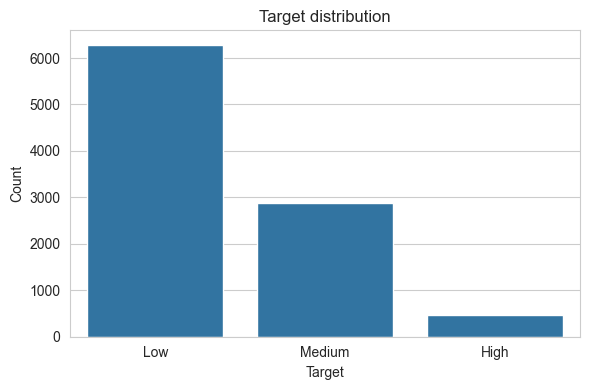

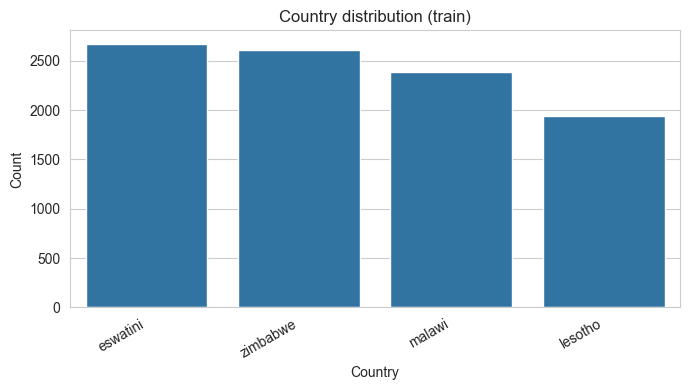

In [10]:
# Quick plots: target distribution + country distribution
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')

if 'Target' in train_dataset.columns:
    plt.figure(figsize=(6, 4))
    ax = sns.countplot(data=train_dataset, x='Target', order=train_dataset['Target'].value_counts().index)
    ax.set_title('Target distribution')
    ax.set_xlabel('Target')
    ax.set_ylabel('Count')
    plt.tight_layout()
    plt.show()

if 'country' in train_dataset.columns:
    plt.figure(figsize=(7, 4))
    ax = sns.countplot(data=train_dataset, x='country', order=train_dataset['country'].value_counts().index)
    ax.set_title('Country distribution (train)')
    ax.set_xlabel('Country')
    ax.set_ylabel('Count')
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    plt.show()

In [11]:
# Numeric summary + outlier hints
numeric_cols = train_dataset.select_dtypes(include=[np.number]).columns.tolist()
print('Numeric columns:', len(numeric_cols))
display(train_dataset[numeric_cols].describe().T)

# Look at extreme values for a few key financial columns (if present)
for col in ['personal_income', 'business_expenses', 'business_turnover']:
    if col in train_dataset.columns:
        s = train_dataset[col]
        print(f"\n{col}: min={s.min(skipna=True)}  p1={s.quantile(0.01)}  median={s.median(skipna=True)}  p99={s.quantile(0.99)}  max={s.max(skipna=True)}")

Numeric columns: 6


,count,mean,std,min,25%,50%,75%,max
owner_age,9618.0,4.170534e+01,1.331401e+01,18.0,32.0,40.0,50.0,103.0
personal_income,9509.0,2.627345e+05,2.566268e+06,0.0,300.0,2000.0,25000.0,150000000.0
business_expenses,9389.0,4.583838e+05,6.184746e+06,0.0,700.0,3000.0,25000.0,500000000.0
business_turnover,9402.0,1.348210e+06,8.804741e+06,0.0,1500.0,6000.0,50000.0,420000000.0
business_age_years,9366.0,7.030536e+00,7.650349e+00,0.0,2.0,4.0,10.0,60.0
business_age_months,5507.0,3.636281e+00,3.386488e+00,0.0,0.0,3.0,6.0,11.0



personal_income: min=0.0  p1=20.0  median=2000.0  p99=3129200.000000001  max=150000000.0

business_expenses: min=0.0  p1=40.0  median=3000.0  p99=8019200.0000001285  max=500000000.0

business_turnover: min=0.0  p1=97.0  median=6000.0  p99=24994999.999999892  max=420000000.0


In [12]:
# Categorical feature scan: top values + cardinality
categorical_cols = [c for c in train_dataset.columns if c not in numeric_cols + ['Target']]
print('Categorical columns:', len(categorical_cols))

cardinality = train_dataset[categorical_cols].nunique(dropna=False).sort_values(ascending=False)
display(cardinality.to_frame('n_unique').head(25))

# Show the most common values for a few high-signal columns
for col in ['owner_sex', 'has_mobile_money', 'has_insurance', 'keeps_financial_records']:
    if col in train_dataset.columns:
        print(f"\nValue counts: {col}")
        display(train_dataset[col].value_counts(dropna=False).head(10))

Categorical columns: 32


,n_unique
ID,9618
has_loan_account,7
uses_friends_family_savings,7
medical_insurance,7
has_internet_banking,7
uses_informal_lender,7
perception_insurance_companies_dont_insure_businesses_like_yours,6
has_mobile_money,6
funeral_insurance,6
has_debit_card,6



Value counts: owner_sex


owner_sex
Female    4303
Male      3371
NaN       1944
Name: count, dtype: int64


Value counts: has_mobile_money


has_mobile_money
Have now                           4876
NaN                                2751
Never had                          1842
Used to have but don't have now      82
Used to have but don’t have now      61
Don't know                            6
Name: count, dtype: int64


Value counts: has_insurance


has_insurance
No     7375
NaN    1956
Yes     287
Name: count, dtype: int64


Value counts: keeps_financial_records


keeps_financial_records
No                3334
NaN               1949
Yes, sometimes    1671
Yes, always       1525
Yes               1139
Name: count, dtype: int64

In [13]:
# Relationship check: simple target vs. a few features
if 'Target' in train_dataset.columns:
    cols_to_check = ['country', 'keeps_financial_records', 'has_insurance', 'current_problem_cash_flow']
    for col in cols_to_check:
        if col in train_dataset.columns:
            ct = pd.crosstab(train_dataset[col], train_dataset['Target'], normalize='index').round(3)
            print(f"\nP(Target | {col})")
            display(ct)


P(Target | country)


Target,High,Low,Medium
country,,,
eswatini,0.115,0.514,0.371
lesotho,0.003,0.604,0.393
malawi,0.040,0.812,0.147
zimbabwe,0.023,0.686,0.291



P(Target | keeps_financial_records)


Target,High,Low,Medium
keeps_financial_records,,,
No,0.020,0.779,0.201
Yes,0.071,0.739,0.190
"Yes, always",0.153,0.445,0.402
"Yes, sometimes",0.048,0.591,0.360



P(Target | has_insurance)


Target,High,Low,Medium
has_insurance,,,
No,0.049,0.691,0.260
Yes,0.359,0.000,0.641



P(Target | current_problem_cash_flow)


Target,High,Low,Medium
current_problem_cash_flow,,,
0,0.099,0.537,0.364
No,0.044,0.812,0.144
Yes,0.076,0.596,0.328


In [14]:
# (Optional) Load variable definitions for easier interpretation
try:
    var_defs = read_csv_case_safe('VariableDefinitions.csv')
    display(var_defs.head(30))
except Exception as e:
    print('Could not load VariableDefinitions.csv:', e)

,VARIABLE_NAME,VARIABLE_DESCRIPTION
0,ID,Unique identifier for each business record
1,country,Country where the business is located (Eswatin...
2,owner_age,Age of the business owner in years
3,attitude_stable_business_environment,Owner attitude: Country will have a stable bus...
4,attitude_worried_shutdown,Owner attitude: Worried that the business will...
5,compliance_income_tax,Business complies with or acts in accordance w...
6,perception_insurance_doesnt_cover_losses,Owner perception: Insurance does not cover the...
7,perception_cannot_afford_insurance,Owner perception: Cannot afford insurance paym...
8,personal_income,Total monthly personal income of the owner bef...
9,business_expenses,Approximate monthly or annual expenses of the ...


## Phase 2: Feature Engineering & Selection

This section implements all Phase 2 tasks from the work guide:

1. **Domain-Driven Features**:
   - Financial Access Index: banking + insurance + mobile money
   - Formality Index: tax compliance + record-keeping + formal credit
   - Risk Index: cash-flow problems + theft risk + worried shutdown

2. **Interaction Features**:
   - owner_age × business_age_years (experience proxy)
   - cash_flow_problem × has_loan_account (stress-with-leverage)
   - insurance_important × has_insurance (alignment signal)

3. **Ordinal Encoding** for ordered categorical responses

4. **Feature Selection** via multiple methods with ensemble ranking

5. **Systematic Comparison Loop** to find optimal feature sets for each model

In [3]:
# =============================================================================
# PHASE 2: COMPREHENSIVE FEATURE ENGINEERING
# =============================================================================

import numpy as np
import pandas as pd
from typing import Dict, List, Tuple

# Reload data to ensure clean state
train_df = read_csv_case_safe('Train.csv')
test_df = read_csv_case_safe('Test.csv')

print(f"Train shape: {train_df.shape}, Test shape: {test_df.shape}")

# =============================================================================
# 1. ORDINAL ENCODING MAPPINGS for ordered categorical responses
# =============================================================================

# Define ordinal mappings for features with natural ordering
ORDINAL_MAPPINGS = {
    # "Have/Had/Never" patterns (common across financial product ownership)
    'have_status': {
        'Never had': 0,
        'Used to have but don\'t have now': 1,
        "Used to have but don't have now": 1,  # Handle encoding variations
        'Have now': 2,
        np.nan: -1,  # Missing
    },
    # Yes/No patterns
    'yes_no': {
        'No': 0,
        'Yes': 1,
        np.nan: -1,
    },
    # Yes sometimes patterns
    'yes_sometimes': {
        'No': 0,
        'Yes, sometimes': 1,
        'Yes, always': 2,
        np.nan: -1,
    },
    # Attitude/Perception patterns (typically Yes/No/Don't know)
    'attitude': {
        'No': 0,
        "Don't know or N/A": 0.5,
        "Don?t know / doesn?t apply": 0.5,
        "Don't know": 0.5,
        'Yes': 1,
        np.nan: -1,
    }
}

# Map columns to their ordinal encoding type
COLUMN_ORDINAL_TYPE = {
    # Financial product ownership (have/had/never pattern)
    'motor_vehicle_insurance': 'have_status',
    'has_mobile_money': 'have_status',
    'has_credit_card': 'have_status',
    'has_loan_account': 'have_status',
    'has_internet_banking': 'have_status',
    'has_debit_card': 'have_status',
    'medical_insurance': 'have_status',
    'funeral_insurance': 'have_status',
    'uses_friends_family_savings': 'have_status',
    'uses_informal_lender': 'have_status',
    
    # Yes/No columns
    'has_insurance': 'yes_no',
    'covid_essential_service': 'yes_no',
    'current_problem_cash_flow': 'yes_no',
    'has_cellphone': 'yes_no',
    'compliance_income_tax': 'yes_no',
    'problem_sourcing_money': 'yes_no',
    'marketing_word_of_mouth': 'yes_no',
    'future_risk_theft_stock': 'yes_no',
    'motivation_make_more_money': 'yes_no',
    
    # Yes sometimes/always patterns
    'offers_credit_to_customers': 'yes_sometimes',
    'keeps_financial_records': 'yes_sometimes',
    
    # Attitude/perception columns
    'attitude_stable_business_environment': 'attitude',
    'attitude_worried_shutdown': 'attitude',
    'attitude_satisfied_with_achievement': 'attitude',
    'attitude_more_successful_next_year': 'attitude',
    'perception_insurance_doesnt_cover_losses': 'attitude',
    'perception_cannot_afford_insurance': 'attitude',
    'perception_insurance_companies_dont_insure_businesses_like_yours': 'attitude',
    'perception_insurance_important': 'attitude',
}

def apply_ordinal_encoding(df: pd.DataFrame, col: str, mapping_type: str) -> pd.Series:
    """Apply ordinal encoding to a column based on mapping type."""
    mapping = ORDINAL_MAPPINGS.get(mapping_type, {})
    
    # Create a function that handles the mapping with fallback
    def map_value(val):
        if pd.isna(val):
            return -1
        # Try exact match first
        if val in mapping:
            return mapping[val]
        # Try case-insensitive match
        for k, v in mapping.items():
            if isinstance(k, str) and isinstance(val, str) and k.lower() == val.lower():
                return v
        # Default to -1 for unknown values
        return -1
    
    return df[col].apply(map_value)

print("Ordinal mappings defined for", len(COLUMN_ORDINAL_TYPE), "columns")
print("Mapping types:", list(ORDINAL_MAPPINGS.keys()))

Train shape: (9618, 39), Test shape: (2405, 38)
Ordinal mappings defined for 29 columns
Mapping types: ['have_status', 'yes_no', 'yes_sometimes', 'attitude']


In [4]:
# =============================================================================
# 2. DOMAIN-DRIVEN FEATURE ENGINEERING FUNCTIONS
# =============================================================================

def create_financial_access_index(df: pd.DataFrame) -> pd.Series:
    """
    Financial Access Index: Sum of banking/insurance/mobile money access.
    Higher = more financial inclusion.
    """
    access_cols = [
        'has_mobile_money', 'has_loan_account', 'has_internet_banking',
        'has_debit_card', 'has_credit_card', 'has_insurance'
    ]
    
    # Convert to binary (1 if "Have now" or "Yes", 0 otherwise)
    access_scores = pd.DataFrame()
    for col in access_cols:
        if col in df.columns:
            s = df[col].astype(str).str.lower()
            access_scores[col] = ((s == 'have now') | (s == 'yes')).astype(int)
    
    return access_scores.sum(axis=1) if len(access_scores.columns) > 0 else pd.Series(0, index=df.index)


def create_formality_index(df: pd.DataFrame) -> pd.Series:
    """
    Formality Index: Measures business formalization level.
    Based on tax compliance, record-keeping, formal credit usage.
    """
    formality_indicators = []
    
    # Tax compliance
    if 'compliance_income_tax' in df.columns:
        formality_indicators.append(
            (df['compliance_income_tax'].astype(str).str.lower() == 'yes').astype(int)
        )
    
    # Record keeping (Yes, always = 2, Yes sometimes = 1, No = 0)
    if 'keeps_financial_records' in df.columns:
        s = df['keeps_financial_records'].astype(str).str.lower()
        records_score = np.where(s.str.contains('always'), 2, 
                                 np.where(s.str.contains('sometimes'), 1, 0))
        formality_indicators.append(pd.Series(records_score, index=df.index))
    
    # Formal credit (loan account, credit card)
    for col in ['has_loan_account', 'has_credit_card']:
        if col in df.columns:
            s = df[col].astype(str).str.lower()
            formality_indicators.append((s == 'have now').astype(int))
    
    if formality_indicators:
        return pd.concat(formality_indicators, axis=1).sum(axis=1)
    return pd.Series(0, index=df.index)


def create_risk_index(df: pd.DataFrame) -> pd.Series:
    """
    Risk Index: Aggregates business risk indicators.
    Higher = more risk exposure.
    """
    risk_indicators = []
    
    # Cash flow problems
    if 'current_problem_cash_flow' in df.columns:
        risk_indicators.append(
            (df['current_problem_cash_flow'].astype(str).str.lower() == 'yes').astype(int)
        )
    
    # Theft risk
    if 'future_risk_theft_stock' in df.columns:
        risk_indicators.append(
            (df['future_risk_theft_stock'].astype(str).str.lower() == 'yes').astype(int)
        )
    
    # Worried about shutdown
    if 'attitude_worried_shutdown' in df.columns:
        risk_indicators.append(
            (df['attitude_worried_shutdown'].astype(str).str.lower() == 'yes').astype(int)
        )
    
    # Problem sourcing money
    if 'problem_sourcing_money' in df.columns:
        risk_indicators.append(
            (df['problem_sourcing_money'].astype(str).str.lower() == 'yes').astype(int)
        )
    
    if risk_indicators:
        return pd.concat(risk_indicators, axis=1).sum(axis=1)
    return pd.Series(0, index=df.index)


def create_insurance_attitude_index(df: pd.DataFrame) -> pd.Series:
    """
    Insurance Attitude Index: Perception vs action alignment.
    Positive = believes insurance is important AND has insurance.
    """
    score = pd.Series(0, index=df.index)
    
    # Believes insurance is important
    if 'perception_insurance_important' in df.columns:
        believes_important = (df['perception_insurance_important'].astype(str).str.lower() == 'yes').astype(int)
        score += believes_important
    
    # Actually has insurance
    if 'has_insurance' in df.columns:
        has_ins = (df['has_insurance'].astype(str).str.lower() == 'yes').astype(int)
        score += has_ins * 2  # Weight actual behavior more
    
    return score


def create_business_maturity_score(df: pd.DataFrame) -> pd.Series:
    """
    Business Maturity Score: Combines owner experience with business age.
    """
    score = pd.Series(0.0, index=df.index)
    
    if 'business_age_years' in df.columns:
        # Normalize business age (cap at 20 years)
        ba = df['business_age_years'].fillna(0).clip(0, 20) / 20.0
        score += ba
    
    if 'owner_age' in df.columns:
        # Normalize owner age (assume 18-70 range)
        oa = (df['owner_age'].fillna(35) - 18).clip(0, 52) / 52.0
        score += oa
    
    return score


print("Domain-driven feature functions defined:"
      "\n  - Financial Access Index"
      "\n  - Formality Index"  
      "\n  - Risk Index"
      "\n  - Insurance Attitude Index"
      "\n  - Business Maturity Score")

Domain-driven feature functions defined:
  - Financial Access Index
  - Formality Index
  - Risk Index
  - Insurance Attitude Index
  - Business Maturity Score


In [5]:
# =============================================================================
# 3. INTERACTION FEATURES
# =============================================================================

def create_interaction_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Create interaction features as specified in the work guide:
    - owner_age × business_age_years (experience proxy)
    - cash_flow_problem × has_loan_account (stress-with-leverage)
    - insurance_important × has_insurance (alignment signal)
    """
    interactions = pd.DataFrame(index=df.index)
    
    # 1. Experience Proxy: owner_age × business_age_years
    if 'owner_age' in df.columns and 'business_age_years' in df.columns:
        owner_age = df['owner_age'].fillna(df['owner_age'].median())
        business_age = df['business_age_years'].fillna(0)
        interactions['interaction_experience_proxy'] = owner_age * business_age
        # Also add normalized version
        interactions['interaction_experience_ratio'] = business_age / (owner_age - 18 + 1).clip(lower=1)
    
    # 2. Stress-with-Leverage: cash_flow_problem × has_loan_account
    if 'current_problem_cash_flow' in df.columns and 'has_loan_account' in df.columns:
        cash_flow_problem = (df['current_problem_cash_flow'].astype(str).str.lower() == 'yes').astype(int)
        has_loan = (df['has_loan_account'].astype(str).str.lower() == 'have now').astype(int)
        interactions['interaction_stress_leverage'] = cash_flow_problem * has_loan
        # Also: cash flow problem without loan (may indicate need for credit)
        interactions['interaction_cashflow_no_loan'] = cash_flow_problem * (1 - has_loan)
    
    # 3. Insurance Alignment: insurance_important × has_insurance
    if 'perception_insurance_important' in df.columns and 'has_insurance' in df.columns:
        believes_important = (df['perception_insurance_important'].astype(str).str.lower() == 'yes').astype(int)
        has_insurance = (df['has_insurance'].astype(str).str.lower() == 'yes').astype(int)
        # Aligned = both True or both False
        interactions['interaction_insurance_aligned'] = ((believes_important == has_insurance)).astype(int)
        # Mismatch: believes important but doesn't have
        interactions['interaction_insurance_gap'] = (believes_important * (1 - has_insurance)).astype(int)
    
    # 4. Additional useful interactions
    # Turnover per business age (productivity proxy)
    if 'business_turnover' in df.columns and 'business_age_years' in df.columns:
        turnover = df['business_turnover'].fillna(0)
        business_age = df['business_age_years'].fillna(1).clip(lower=0.5)
        interactions['interaction_turnover_per_year'] = turnover / business_age
    
    # Profit margin proxy: (turnover - expenses) / turnover
    if 'business_turnover' in df.columns and 'business_expenses' in df.columns:
        turnover = df['business_turnover'].fillna(0)
        expenses = df['business_expenses'].fillna(0)
        margin = (turnover - expenses) / (turnover + 1)
        interactions['interaction_profit_margin'] = margin.clip(-1, 1)
    
    # Mobile money × no bank account (mobile-only banking)
    if 'has_mobile_money' in df.columns and 'has_loan_account' in df.columns:
        has_mobile = (df['has_mobile_money'].astype(str).str.lower() == 'have now').astype(int)
        no_bank = (df['has_loan_account'].astype(str).str.lower() != 'have now').astype(int)
        interactions['interaction_mobile_only'] = has_mobile * no_bank
    
    return interactions

# Test interaction features
test_interactions = create_interaction_features(train_df)
print(f"Created {len(test_interactions.columns)} interaction features:")
for col in test_interactions.columns:
    print(f"  - {col}: non-null={test_interactions[col].notna().sum()}, unique={test_interactions[col].nunique()}")

Created 9 interaction features:
  - interaction_experience_proxy: non-null=9618, unique=868
  - interaction_experience_ratio: non-null=9618, unique=839
  - interaction_stress_leverage: non-null=9618, unique=2
  - interaction_cashflow_no_loan: non-null=9618, unique=2
  - interaction_insurance_aligned: non-null=9618, unique=2
  - interaction_insurance_gap: non-null=9618, unique=2
  - interaction_turnover_per_year: non-null=9618, unique=1789
  - interaction_profit_margin: non-null=9618, unique=4398
  - interaction_mobile_only: non-null=9618, unique=2


In [6]:
# =============================================================================
# 4. COMPREHENSIVE FEATURE ENGINEERING PIPELINE
# =============================================================================

def engineer_all_features(df: pd.DataFrame, apply_ordinal: bool = True) -> pd.DataFrame:
    """
    Apply all Phase 2 feature engineering to a dataframe.
    
    Parameters:
    -----------
    df : pd.DataFrame
        Raw dataframe with original columns
    apply_ordinal : bool
        Whether to apply ordinal encoding to categorical columns
    
    Returns:
    --------
    pd.DataFrame with all engineered features
    """
    result = df.copy()
    
    # ----- 1. Log transforms for skewed financial features -----
    financial_cols = ['personal_income', 'business_turnover', 'business_expenses']
    for col in financial_cols:
        if col in result.columns:
            result[f'log_{col}'] = np.log1p(result[col].fillna(0).clip(lower=0))
    
    # ----- 2. Ratio features -----
    if 'business_expenses' in result.columns and 'business_turnover' in result.columns:
        result['ratio_expenses_turnover'] = result['business_expenses'] / (result['business_turnover'] + 1)
    
    if 'business_turnover' in result.columns and 'personal_income' in result.columns:
        result['ratio_turnover_income'] = result['business_turnover'] / (result['personal_income'] + 1)
    
    if 'business_expenses' in result.columns and 'personal_income' in result.columns:
        result['ratio_expenses_income'] = result['business_expenses'] / (result['personal_income'] + 1)
    
    # ----- 3. Domain-Driven Index Features -----
    result['idx_financial_access'] = create_financial_access_index(result)
    result['idx_formality'] = create_formality_index(result)
    result['idx_risk'] = create_risk_index(result)
    result['idx_insurance_attitude'] = create_insurance_attitude_index(result)
    result['idx_business_maturity'] = create_business_maturity_score(result)
    
    # ----- 4. Interaction Features -----
    interactions = create_interaction_features(result)
    for col in interactions.columns:
        result[col] = interactions[col]
    
    # ----- 5. Ordinal Encoding (optional) -----
    if apply_ordinal:
        for col, mapping_type in COLUMN_ORDINAL_TYPE.items():
            if col in result.columns:
                result[f'ord_{col}'] = apply_ordinal_encoding(result, col, mapping_type)
    
    # ----- 6. Country encoding (one-hot for now, could also be target-encoded) -----
    if 'country' in result.columns:
        country_dummies = pd.get_dummies(result['country'], prefix='country', dummy_na=False)
        for col in country_dummies.columns:
            result[col] = country_dummies[col]
    
    # ----- 7. Owner sex encoding -----
    if 'owner_sex' in result.columns:
        result['is_female'] = (result['owner_sex'].astype(str).str.lower() == 'female').astype(int)
    
    # ----- 8. Business age in total months -----
    if 'business_age_years' in result.columns and 'business_age_months' in result.columns:
        years = result['business_age_years'].fillna(0)
        months = result['business_age_months'].fillna(0)
        result['business_total_months'] = years * 12 + months
    
    return result


# Apply feature engineering to both train and test
print("Applying comprehensive feature engineering...")
train_engineered = engineer_all_features(train_df, apply_ordinal=True)
test_engineered = engineer_all_features(test_df, apply_ordinal=True)

print(f"\nOriginal train columns: {len(train_df.columns)}")
print(f"Engineered train columns: {len(train_engineered.columns)}")
print(f"\nNew features created: {len(train_engineered.columns) - len(train_df.columns)}")

# Show new columns
new_cols = [c for c in train_engineered.columns if c not in train_df.columns]
print(f"\nNew feature columns ({len(new_cols)}):")
for i, col in enumerate(new_cols):
    print(f"  {i+1}. {col}")

Applying comprehensive feature engineering...

Original train columns: 39
Engineered train columns: 94

New features created: 55

New feature columns (55):
  1. log_personal_income
  2. log_business_turnover
  3. log_business_expenses
  4. ratio_expenses_turnover
  5. ratio_turnover_income
  6. ratio_expenses_income
  7. idx_financial_access
  8. idx_formality
  9. idx_risk
  10. idx_insurance_attitude
  11. idx_business_maturity
  12. interaction_experience_proxy
  13. interaction_experience_ratio
  14. interaction_stress_leverage
  15. interaction_cashflow_no_loan
  16. interaction_insurance_aligned
  17. interaction_insurance_gap
  18. interaction_turnover_per_year
  19. interaction_profit_margin
  20. interaction_mobile_only
  21. ord_motor_vehicle_insurance
  22. ord_has_mobile_money
  23. ord_has_credit_card
  24. ord_has_loan_account
  25. ord_has_internet_banking
  26. ord_has_debit_card
  27. ord_medical_insurance
  28. ord_funeral_insurance
  29. ord_uses_friends_family_savin

In [7]:
# =============================================================================
# 5. FEATURE SET DEFINITIONS FOR COMPARISON
# =============================================================================

"""
We'll define multiple feature sets to compare:
1. Baseline: Original numeric + one-hot encoded categoricals
2. Engineered: Baseline + log transforms + ratios + domain indices
3. Ordinal: Engineered + ordinal encoded categoricals (replacing one-hot for some)
4. Selected: Top features from importance analysis
5. Minimal: Only the most important features (for interpretability)
"""

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
import re

TARGET = 'Target'
ID_COL = 'ID'

# Get feature columns (excluding ID and Target)
def get_feature_columns(df, exclude_cols=None):
    """Get all feature columns from dataframe."""
    exclude = set([ID_COL, TARGET] + (exclude_cols or []))
    return [c for c in df.columns if c not in exclude]

# Define different feature sets
def define_feature_sets(df_engineered: pd.DataFrame) -> Dict[str, List[str]]:
    """Define different feature sets for comparison."""
    
    all_features = get_feature_columns(df_engineered)
    
    # Original features (before engineering)
    original_features = [
        'owner_age', 'personal_income', 'business_expenses', 'business_turnover',
        'business_age_years', 'business_age_months', 'country', 'owner_sex',
        'attitude_stable_business_environment', 'attitude_worried_shutdown',
        'compliance_income_tax', 'perception_insurance_doesnt_cover_losses',
        'perception_cannot_afford_insurance', 'motor_vehicle_insurance',
        'has_mobile_money', 'current_problem_cash_flow', 'has_cellphone',
        'offers_credit_to_customers', 'attitude_satisfied_with_achievement',
        'has_credit_card', 'keeps_financial_records',
        'perception_insurance_companies_dont_insure_businesses_like_yours',
        'perception_insurance_important', 'has_insurance', 'covid_essential_service',
        'attitude_more_successful_next_year', 'problem_sourcing_money',
        'marketing_word_of_mouth', 'has_loan_account', 'has_internet_banking',
        'has_debit_card', 'future_risk_theft_stock', 'medical_insurance',
        'funeral_insurance', 'motivation_make_more_money',
        'uses_friends_family_savings', 'uses_informal_lender'
    ]
    original_features = [f for f in original_features if f in df_engineered.columns]
    
    # Engineered features (log, ratio, indices, interactions)
    engineered_only = [c for c in all_features if 
                       c.startswith('log_') or 
                       c.startswith('ratio_') or 
                       c.startswith('idx_') or 
                       c.startswith('interaction_') or
                       c.startswith('country_') or
                       c in ['is_female', 'business_total_months']]
    
    # Ordinal encoded features
    ordinal_features = [c for c in all_features if c.startswith('ord_')]
    
    # Numeric features only
    numeric_features = df_engineered[all_features].select_dtypes(include=[np.number]).columns.tolist()
    
    # Define feature sets
    feature_sets = {
        # Set 1: Baseline (original features only)
        'baseline': original_features,
        
        # Set 2: Original + Engineered numeric features
        'engineered': original_features + engineered_only,
        
        # Set 3: Numeric only (ordinal + engineered, no one-hot)
        'numeric_ordinal': [f for f in numeric_features if not f.startswith('country_')],
        
        # Set 4: All numeric features including country dummies
        'all_numeric': numeric_features,
        
        # Set 5: Domain indices + ordinal only (compact)
        'indices_ordinal': (
            [c for c in all_features if c.startswith('idx_')] +
            [c for c in all_features if c.startswith('interaction_')] +
            ordinal_features +
            ['log_personal_income', 'log_business_turnover', 'log_business_expenses',
             'ratio_expenses_turnover', 'ratio_turnover_income', 'owner_age',
             'business_total_months', 'is_female'] +
            [c for c in all_features if c.startswith('country_')]
        ),
        
        # Set 6: Everything
        'all_features': all_features,
    }
    
    # Filter to only include features that exist
    for key in feature_sets:
        feature_sets[key] = [f for f in feature_sets[key] if f in df_engineered.columns]
    
    return feature_sets


feature_sets = define_feature_sets(train_engineered)

print("Feature Sets Defined:")
print("=" * 60)
for name, features in feature_sets.items():
    print(f"\n{name}: {len(features)} features")
    if len(features) <= 10:
        print(f"  Features: {features}")
    else:
        print(f"  Sample: {features[:5]} ... {features[-3:]}")

Feature Sets Defined:

baseline: 37 features
  Sample: ['owner_age', 'personal_income', 'business_expenses', 'business_turnover', 'business_age_years'] ... ['motivation_make_more_money', 'uses_friends_family_savings', 'uses_informal_lender']

engineered: 63 features
  Sample: ['owner_age', 'personal_income', 'business_expenses', 'business_turnover', 'business_age_years'] ... ['country_zimbabwe', 'is_female', 'business_total_months']

numeric_ordinal: 57 features
  Sample: ['owner_age', 'personal_income', 'business_expenses', 'business_turnover', 'business_age_years'] ... ['ord_perception_insurance_important', 'is_female', 'business_total_months']

all_numeric: 57 features
  Sample: ['owner_age', 'personal_income', 'business_expenses', 'business_turnover', 'business_age_years'] ... ['ord_perception_insurance_important', 'is_female', 'business_total_months']

indices_ordinal: 55 features
  Sample: ['idx_financial_access', 'idx_formality', 'idx_risk', 'idx_insurance_attitude', 'idx_busine

In [8]:
# =============================================================================
# 6. PREPROCESSING PIPELINE FOR EACH FEATURE SET
# =============================================================================

def create_preprocessor_for_features(feature_list: List[str], df_reference: pd.DataFrame) -> ColumnTransformer:
    """
    Create a preprocessor pipeline for a specific feature set.
    Handles numeric and categorical features appropriately.
    """
    # Separate numeric and categorical features
    numeric_feats = []
    categorical_feats = []
    
    for feat in feature_list:
        if feat in df_reference.columns:
            if df_reference[feat].dtype in ['int64', 'float64', 'int32', 'float32']:
                numeric_feats.append(feat)
            else:
                categorical_feats.append(feat)
    
    transformers = []
    
    # Numeric pipeline
    if numeric_feats:
        numeric_pipeline = Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())  # Normalize for consistent model behavior
        ])
        transformers.append(('num', numeric_pipeline, numeric_feats))
    
    # Categorical pipeline
    if categorical_feats:
        categorical_pipeline = Pipeline([
            ('imputer', SimpleImputer(strategy='constant', fill_value='Missing')),
            ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
        ])
        transformers.append(('cat', categorical_pipeline, categorical_feats))
    
    return ColumnTransformer(
        transformers=transformers,
        remainder='drop',
        verbose_feature_names_out=False
    )


def sanitize_feature_names(names):
    """Sanitize feature names to avoid issues with LightGBM and other models."""
    new_names = []
    seen = set()
    for n in names:
        clean = re.sub(r'[^A-Za-z0-9_]', '_', str(n))
        if clean in seen:
            i = 1
            while f"{clean}_{i}" in seen:
                i += 1
            clean = f"{clean}_{i}"
        seen.add(clean)
        new_names.append(clean)
    return new_names


print("Preprocessing pipeline functions defined.")

Preprocessing pipeline functions defined.


In [10]:
# =============================================================================
# 7. MODEL DEFINITIONS
# =============================================================================

from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import f1_score, make_scorer
from sklearn.utils.class_weight import compute_sample_weight
import xgboost as xgb
from lightgbm import LGBMClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

RANDOM_STATE = 42

def get_models() -> Dict[str, object]:
    """Return dictionary of models to evaluate."""
    
    models = {
        'XGBoost': xgb.XGBClassifier(
            objective='multi:softprob',
            n_estimators=500,
            learning_rate=0.05,
            max_depth=6,
            subsample=0.8,
            colsample_bytree=0.8,
            reg_lambda=1.0,
            min_child_weight=3,
            tree_method='hist',
            random_state=RANDOM_STATE,
            n_jobs=-1,
            eval_metric='mlogloss',
        ),
        
        'LightGBM': LGBMClassifier(
            objective='multiclass',
            n_estimators=500,
            learning_rate=0.05,
            max_depth=-1,
            num_leaves=31,
            subsample=0.8,
            colsample_bytree=0.8,
            reg_lambda=1.0,
            min_child_samples=20,
            random_state=RANDOM_STATE,
            n_jobs=-1,
            verbose=-1,
        ),
        
        'RandomForest': RandomForestClassifier(
            n_estimators=300,
            max_depth=15,
            min_samples_split=5,
            min_samples_leaf=2,
            class_weight='balanced',
            random_state=RANDOM_STATE,
            n_jobs=-1,
        ),
        
        'GradientBoosting': GradientBoostingClassifier(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=5,
            min_samples_split=5,
            min_samples_leaf=2,
            subsample=0.8,
            random_state=RANDOM_STATE,
        ),
        
        'LogisticRegression': LogisticRegression(
            C=1.0,
            max_iter=1000,
            class_weight='balanced',
            solver='lbfgs',
            random_state=RANDOM_STATE,
            n_jobs=-1,
        ),
    }
    
    return models


print(f"Models defined: {list(get_models().keys())}")

Models defined: ['XGBoost', 'LightGBM', 'RandomForest', 'GradientBoosting', 'LogisticRegression']


In [11]:
# =============================================================================
# 8. MAIN COMPARISON LOOP: Feature Sets × Models
# =============================================================================

from sklearn.base import clone
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

def run_feature_model_comparison(
    train_df: pd.DataFrame,
    feature_sets: Dict[str, List[str]],
    n_folds: int = 5,
    verbose: bool = True
) -> pd.DataFrame:
    """
    Run cross-validation for each combination of feature set and model.
    
    Returns a DataFrame with F1-macro scores for each combination.
    """
    
    # Prepare target
    y = train_df[TARGET]
    le = LabelEncoder()
    y_encoded = le.fit_transform(y)
    
    # Prepare results storage
    results = []
    
    # Get models
    models = get_models()
    
    # CV splitter
    skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=RANDOM_STATE)
    
    # Total iterations for progress bar
    total_iters = len(feature_sets) * len(models)
    
    if verbose:
        print(f"Running {total_iters} experiments ({len(feature_sets)} feature sets × {len(models)} models)")
        print(f"Using {n_folds}-fold stratified cross-validation")
        print("=" * 80)
    
    pbar = tqdm(total=total_iters, desc="Experiments") if verbose else None
    
    for feat_set_name, feature_list in feature_sets.items():
        if verbose:
            print(f"\n📊 Feature Set: {feat_set_name} ({len(feature_list)} features)")
        
        # Create preprocessor for this feature set
        preprocessor = create_preprocessor_for_features(feature_list, train_df)
        
        # Prepare features
        X_raw = train_df[feature_list]
        
        for model_name, model_template in models.items():
            fold_scores = []
            
            for fold_idx, (train_idx, val_idx) in enumerate(skf.split(X_raw, y_encoded)):
                # Split data
                X_train_fold = X_raw.iloc[train_idx]
                X_val_fold = X_raw.iloc[val_idx]
                y_train_fold = y_encoded[train_idx]
                y_val_fold = y_encoded[val_idx]
                
                # Fit preprocessor on training fold
                try:
                    X_train_processed = preprocessor.fit_transform(X_train_fold)
                    X_val_processed = preprocessor.transform(X_val_fold)
                except Exception as e:
                    if verbose:
                        print(f"  ⚠️ Preprocessing error for {feat_set_name}: {e}")
                    fold_scores.append(np.nan)
                    continue
                
                # Sanitize feature names if needed
                if hasattr(preprocessor, 'get_feature_names_out'):
                    try:
                        feat_names = sanitize_feature_names(preprocessor.get_feature_names_out())
                        X_train_processed = pd.DataFrame(X_train_processed, columns=feat_names)
                        X_val_processed = pd.DataFrame(X_val_processed, columns=feat_names)
                    except:
                        pass
                
                # Compute sample weights for balanced training
                sample_weights = compute_sample_weight('balanced', y_train_fold)
                
                # Clone and train model
                model = clone(model_template)
                
                try:
                    # Handle sample weights for different model types
                    if model_name in ['XGBoost', 'LightGBM']:
                        model.fit(X_train_processed, y_train_fold, sample_weight=sample_weights)
                    elif model_name in ['RandomForest', 'GradientBoosting']:
                        model.fit(X_train_processed, y_train_fold, sample_weight=sample_weights)
                    else:
                        model.fit(X_train_processed, y_train_fold)
                    
                    # Predict and score
                    y_pred = model.predict(X_val_processed)
                    f1 = f1_score(y_val_fold, y_pred, average='macro')
                    fold_scores.append(f1)
                    
                except Exception as e:
                    if verbose:
                        print(f"  ⚠️ Training error for {model_name}: {e}")
                    fold_scores.append(np.nan)
            
            # Record results
            mean_f1 = np.nanmean(fold_scores)
            std_f1 = np.nanstd(fold_scores)
            
            results.append({
                'feature_set': feat_set_name,
                'model': model_name,
                'n_features': len(feature_list),
                'f1_macro_mean': mean_f1,
                'f1_macro_std': std_f1,
                'fold_scores': fold_scores,
            })
            
            if pbar:
                pbar.update(1)
                pbar.set_postfix({'last_f1': f'{mean_f1:.4f}'})
    
    if pbar:
        pbar.close()
    
    # Create results DataFrame
    results_df = pd.DataFrame(results)
    results_df = results_df.sort_values('f1_macro_mean', ascending=False)
    
    return results_df


print("Comparison loop function defined. Ready to run experiments.")

Comparison loop function defined. Ready to run experiments.


In [12]:
# =============================================================================
# 9. RUN THE COMPARISON EXPERIMENTS
# =============================================================================

print("🚀 Starting Feature Set × Model Comparison")
print("=" * 80)

# Run the comparison
comparison_results = run_feature_model_comparison(
    train_df=train_engineered,
    feature_sets=feature_sets,
    n_folds=5,
    verbose=True
)

print("\n" + "=" * 80)
print("📊 EXPERIMENT RESULTS")
print("=" * 80)

🚀 Starting Feature Set × Model Comparison
Running 30 experiments (6 feature sets × 5 models)
Using 5-fold stratified cross-validation


Experiments:   0%|          | 0/30 [00:00<?, ?it/s]


📊 Feature Set: baseline (37 features)


Experiments:  17%|█▋        | 5/30 [02:09<11:21, 27.25s/it, last_f1=0.7333]


📊 Feature Set: engineered (63 features)


...

  ⚠️ Preprocessing error for indices_ordinal: SimpleImputer does not support data with dtype bool. Please provide either a numeric array (with a floating point or integer dtype) or categorical data represented either as an array with integer dtype or an array of string values with an object dtype.
  ⚠️ Preprocessing error for indices_ordinal: SimpleImputer does not support data with dtype bool. Please provide either a numeric array (with a floating point or integer dtype) or categorical data represented either as an array with integer dtype or an array of string values with an object dtype.
  ⚠️ Preprocessing error for indices_ordinal: SimpleImputer does not support data with dtype bool. Please provide either a numeric array (with a floating point or integer dtype) or categorical data represented either as an array with integer dtype or an array of string values with an object dtype.
  ⚠️ Preprocessing error for indices_ordinal: SimpleImputer does not support data with dtype bool. Plea

Experiments:  83%|████████▎ | 25/30 [11:12<00:46,  9.24s/it, last_f1=nan]

  ⚠️ Preprocessing error for indices_ordinal: SimpleImputer does not support data with dtype bool. Please provide either a numeric array (with a floating point or integer dtype) or categorical data represented either as an array with integer dtype or an array of string values with an object dtype.
  ⚠️ Preprocessing error for indices_ordinal: SimpleImputer does not support data with dtype bool. Please provide either a numeric array (with a floating point or integer dtype) or categorical data represented either as an array with integer dtype or an array of string values with an object dtype.
  ⚠️ Preprocessing error for indices_ordinal: SimpleImputer does not support data with dtype bool. Please provide either a numeric array (with a floating point or integer dtype) or categorical data represented either as an array with integer dtype or an array of string values with an object dtype.

📊 Feature Set: all_features (92 features)


Experiments: 100%|██████████| 30/30 [15:12<00:00, 30.40s/it, last_f1=0.7360]


📊 EXPERIMENT RESULTS


Valid experiments: 25 / 30

🏆 TOP 10 OVERALL RESULTS (by F1-Macro):


,feature_set,model,n_features,f1_macro_mean,f1_macro_std
26,all_features,LightGBM,92,0.801962,0.014903
11,numeric_ordinal,LightGBM,57,0.801733,0.016246
16,all_numeric,LightGBM,57,0.801733,0.016246
1,baseline,LightGBM,37,0.801353,0.009372
0,baseline,XGBoost,37,0.800377,0.011193
5,engineered,XGBoost,63,0.799339,0.011991
25,all_features,XGBoost,92,0.799208,0.014219
28,all_features,GradientBoosting,92,0.798874,0.014956
10,numeric_ordinal,XGBoost,57,0.798414,0.012908
15,all_numeric,XGBoost,57,0.798414,0.012908



🎯 BEST FEATURE SET FOR EACH MODEL:


,model,feature_set,n_features,f1_macro_mean,f1_macro_std
26,LightGBM,all_features,92,0.801962,0.014903
0,XGBoost,baseline,37,0.800377,0.011193
28,GradientBoosting,all_features,92,0.798874,0.014956
27,RandomForest,all_features,92,0.774276,0.014999
9,LogisticRegression,engineered,63,0.737901,0.015700



📊 BEST MODEL FOR EACH FEATURE SET:


,feature_set,model,n_features,f1_macro_mean,f1_macro_std
26,all_features,LightGBM,92,0.801962,0.014903
16,all_numeric,LightGBM,57,0.801733,0.016246
11,numeric_ordinal,LightGBM,57,0.801733,0.016246
1,baseline,LightGBM,37,0.801353,0.009372
5,engineered,XGBoost,63,0.799339,0.011991



📈 VISUALIZATION: F1-Macro Heatmap


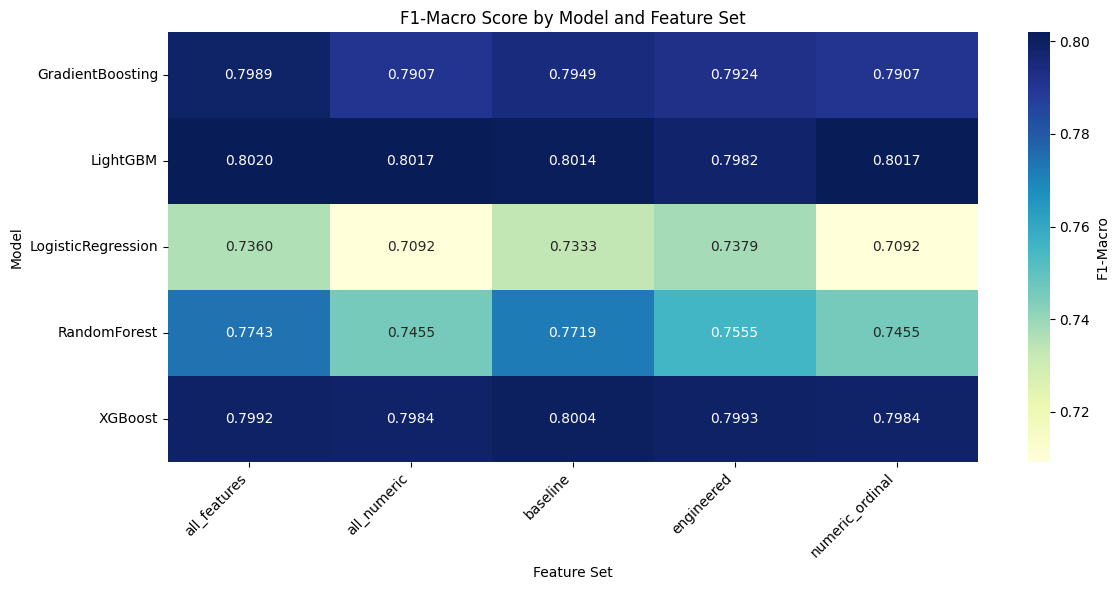

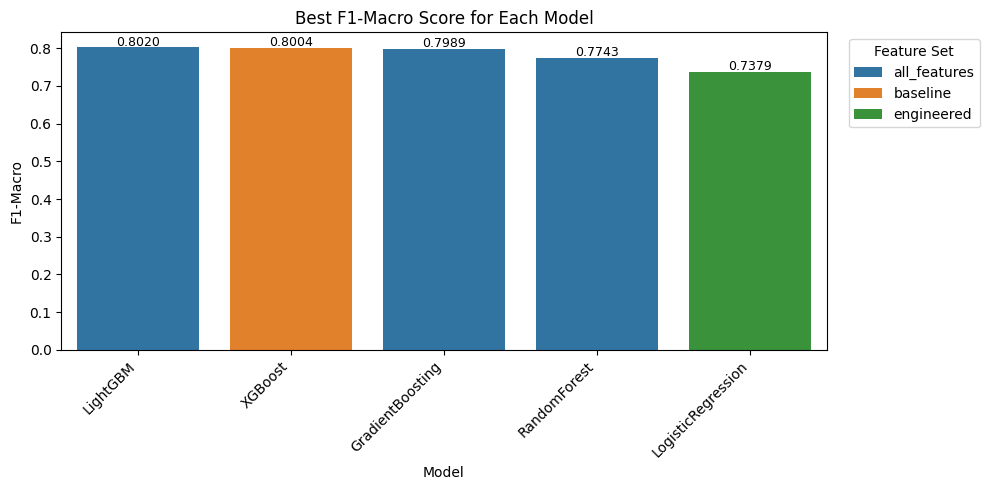

In [14]:
# =============================================================================
# 10. ANALYZE AND VISUALIZE RESULTS
# =============================================================================

import matplotlib.pyplot as plt
import seaborn as sns

# Filter out NaN results (failed experiments)
valid_results = comparison_results[comparison_results['f1_macro_mean'].notna()].copy()
print(f"Valid experiments: {len(valid_results)} / {len(comparison_results)}")

# Display top results
print("\n🏆 TOP 10 OVERALL RESULTS (by F1-Macro):")
display(valid_results[['feature_set', 'model', 'n_features', 'f1_macro_mean', 'f1_macro_std']].head(10))

# Best result per model
print("\n🎯 BEST FEATURE SET FOR EACH MODEL:")
best_per_model = valid_results.loc[valid_results.groupby('model')['f1_macro_mean'].idxmax()]
best_per_model = best_per_model.sort_values('f1_macro_mean', ascending=False)
display(best_per_model[['model', 'feature_set', 'n_features', 'f1_macro_mean', 'f1_macro_std']])

# Best result per feature set
print("\n📊 BEST MODEL FOR EACH FEATURE SET:")
best_per_featset = valid_results.loc[valid_results.groupby('feature_set')['f1_macro_mean'].idxmax()]
best_per_featset = best_per_featset.sort_values('f1_macro_mean', ascending=False)
display(best_per_featset[['feature_set', 'model', 'n_features', 'f1_macro_mean', 'f1_macro_std']])

# Visualization: Heatmap of F1 scores
print("\n📈 VISUALIZATION: F1-Macro Heatmap")
pivot_table = valid_results.pivot(index='model', columns='feature_set', values='f1_macro_mean')

plt.figure(figsize=(12, 6))
sns.heatmap(pivot_table, annot=True, fmt='.4f', cmap='YlGnBu', cbar_kws={'label': 'F1-Macro'})
plt.title('F1-Macro Score by Model and Feature Set')
plt.xlabel('Feature Set')
plt.ylabel('Model')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Bar plot of best F1 per model
plt.figure(figsize=(10, 5))
ax = sns.barplot(data=best_per_model, x='model', y='f1_macro_mean', hue='feature_set', dodge=False)
plt.title('Best F1-Macro Score for Each Model')
plt.xlabel('Model')
plt.ylabel('F1-Macro')
plt.xticks(rotation=45, ha='right')
for i, row in enumerate(best_per_model.itertuples()):
    ax.text(i, row.f1_macro_mean + 0.005, f'{row.f1_macro_mean:.4f}', ha='center', fontsize=9)
plt.legend(title='Feature Set', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [15]:
# =============================================================================
# 11. TRAIN BEST CONFIGURATIONS AND GENERATE SUBMISSIONS
# =============================================================================

from sklearn.base import clone
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_sample_weight
import os

def train_and_evaluate_best_config(
    train_df: pd.DataFrame,
    test_df: pd.DataFrame,
    feature_list: List[str],
    model_template: object,
    model_name: str,
    output_filename: str
) -> Tuple[object, pd.DataFrame, Dict]:
    """
    Train a model on full training data and generate submission.
    """
    
    # Prepare data
    y = train_df[TARGET]
    le = LabelEncoder()
    y_encoded = le.fit_transform(y)
    
    X_train_raw = train_df[feature_list]
    X_test_raw = test_df[feature_list]
    
    # Create and fit preprocessor
    preprocessor = create_preprocessor_for_features(feature_list, train_df)
    X_train_processed = preprocessor.fit_transform(X_train_raw)
    X_test_processed = preprocessor.transform(X_test_raw)
    
    # Sanitize feature names
    if hasattr(preprocessor, 'get_feature_names_out'):
        try:
            feat_names = sanitize_feature_names(preprocessor.get_feature_names_out())
            X_train_processed = pd.DataFrame(X_train_processed, columns=feat_names)
            X_test_processed = pd.DataFrame(X_test_processed, columns=feat_names)
        except:
            pass
    
    # Compute sample weights
    sample_weights = compute_sample_weight('balanced', y_encoded)
    
    # Clone and train model
    model = clone(model_template)
    
    if model_name in ['XGBoost', 'LightGBM', 'RandomForest', 'GradientBoosting']:
        model.fit(X_train_processed, y_encoded, sample_weight=sample_weights)
    else:
        model.fit(X_train_processed, y_encoded)
    
    # Generate predictions
    test_pred_encoded = model.predict(X_test_processed)
    test_pred = le.inverse_transform(test_pred_encoded)
    
    # Create submission
    submission = pd.DataFrame({
        'ID': test_df['ID'],
        'Target': test_pred
    })
    
    # Save submission
    submission.to_csv(output_filename, index=False)
    
    # Get prediction distribution
    pred_dist = pd.Series(test_pred).value_counts(normalize=True).to_dict()
    
    return model, submission, {
        'model_name': model_name,
        'n_features': len(feature_list),
        'output_file': output_filename,
        'prediction_distribution': pred_dist,
    }


# Get best overall configuration from valid results
best_overall = valid_results.iloc[0]
print(f"🏆 BEST OVERALL CONFIGURATION:")
print(f"   Model: {best_overall['model']}")
print(f"   Feature Set: {best_overall['feature_set']}")
print(f"   F1-Macro: {best_overall['f1_macro_mean']:.4f} ± {best_overall['f1_macro_std']:.4f}")
print(f"   Features: {best_overall['n_features']}")

# Get the models and feature sets
models = get_models()

# Train and save submissions for top configurations
submissions_info = []

print("\n" + "=" * 80)
print("📤 GENERATING SUBMISSIONS FOR TOP CONFIGURATIONS")
print("=" * 80)

# 1. Best overall
best_model_name = best_overall['model']
best_feature_set_name = best_overall['feature_set']
best_feature_list = feature_sets[best_feature_set_name]

model, submission, info = train_and_evaluate_best_config(
    train_df=train_engineered,
    test_df=test_engineered,
    feature_list=best_feature_list,
    model_template=models[best_model_name],
    model_name=best_model_name,
    output_filename='submission_phase2_best.csv'
)

print(f"\n✅ Saved: submission_phase2_best.csv")
print(f"   Model: {info['model_name']}, Features: {info['n_features']}")
print(f"   Prediction distribution: {info['prediction_distribution']}")
submissions_info.append(info)

# 2. Best per each model (for ensemble possibilities)
for _, row in best_per_model.iterrows():
    model_name = row['model']
    feat_set_name = row['feature_set']
    feat_list = feature_sets[feat_set_name]
    
    filename = f'submission_phase2_{model_name.lower().replace(" ", "_")}.csv'
    
    _, submission, info = train_and_evaluate_best_config(
        train_df=train_engineered,
        test_df=test_engineered,
        feature_list=feat_list,
        model_template=models[model_name],
        model_name=model_name,
        output_filename=filename
    )
    
    print(f"\n✅ Saved: {filename}")
    print(f"   Feature Set: {feat_set_name}, F1: {row['f1_macro_mean']:.4f}")
    print(f"   Prediction distribution: {info['prediction_distribution']}")
    submissions_info.append(info)

🏆 BEST OVERALL CONFIGURATION:
   Model: LightGBM
   Feature Set: all_features
   F1-Macro: 0.8020 ± 0.0149
   Features: 92

📤 GENERATING SUBMISSIONS FOR TOP CONFIGURATIONS

✅ Saved: submission_phase2_best.csv
   Model: LightGBM, Features: 92
   Prediction distribution: {'Low': 0.669022869022869, 'Medium': 0.28981288981288983, 'High': 0.041164241164241167}

✅ Saved: submission_phase2_lightgbm.csv
   Feature Set: all_features, F1: 0.8020
   Prediction distribution: {'Low': 0.669022869022869, 'Medium': 0.28981288981288983, 'High': 0.041164241164241167}

✅ Saved: submission_phase2_xgboost.csv
   Feature Set: baseline, F1: 0.8004
   Prediction distribution: {'Low': 0.6465696465696466, 'Medium': 0.3093555093555094, 'High': 0.04407484407484408}

✅ Saved: submission_phase2_gradientboosting.csv
   Feature Set: all_features, F1: 0.7989
   Prediction distribution: {'Low': 0.6424116424116424, 'Medium': 0.30644490644490646, 'High': 0.051143451143451146}

✅ Saved: submission_phase2_randomforest.csv


In [16]:
# =============================================================================
# 12. SUMMARY AND BEST SUBMISSION SELECTION
# =============================================================================

print("\n" + "=" * 80)
print("📊 PHASE 2 EXPERIMENT SUMMARY")
print("=" * 80)

# Summary table
summary_df = comparison_results.copy()
summary_df['cv_score'] = summary_df['f1_macro_mean'].apply(lambda x: f"{x:.4f}")
summary_df['cv_std'] = summary_df['f1_macro_std'].apply(lambda x: f"±{x:.4f}")

print("\n📋 Complete Results Table:")
display(summary_df[['feature_set', 'model', 'n_features', 'cv_score', 'cv_std']].reset_index(drop=True))

# Key insights
print("\n" + "=" * 80)
print("🔑 KEY INSIGHTS")
print("=" * 80)

# Best feature set overall
feat_set_avg = comparison_results.groupby('feature_set')['f1_macro_mean'].mean().sort_values(ascending=False)
print(f"\n1. Best Feature Set (avg across models): {feat_set_avg.index[0]} (avg F1: {feat_set_avg.iloc[0]:.4f})")

# Best model overall
model_avg = comparison_results.groupby('model')['f1_macro_mean'].mean().sort_values(ascending=False)
print(f"2. Best Model (avg across feature sets): {model_avg.index[0]} (avg F1: {model_avg.iloc[0]:.4f})")

# Feature engineering impact
baseline_f1 = comparison_results[comparison_results['feature_set'] == 'baseline']['f1_macro_mean'].mean()
best_eng_f1 = feat_set_avg.iloc[0]
improvement = ((best_eng_f1 - baseline_f1) / baseline_f1) * 100
print(f"3. Feature Engineering Improvement: {improvement:+.2f}% (baseline: {baseline_f1:.4f} → best: {best_eng_f1:.4f})")

# Variability analysis
low_var_models = comparison_results.groupby('model')['f1_macro_std'].mean().sort_values()
print(f"4. Most Stable Model: {low_var_models.index[0]} (avg std: {low_var_models.iloc[0]:.4f})")

print("\n" + "=" * 80)
print("📁 GENERATED SUBMISSION FILES")
print("=" * 80)

for info in submissions_info:
    print(f"  • {info['output_file']} ({info['model_name']}, {info['n_features']} features)")

print(f"\n🎯 RECOMMENDED SUBMISSION: submission_phase2_best.csv")
print(f"   Based on: {best_overall['model']} with {best_overall['feature_set']} features")
print(f"   CV Score: {best_overall['f1_macro_mean']:.4f} ± {best_overall['f1_macro_std']:.4f}")


📊 PHASE 2 EXPERIMENT SUMMARY

📋 Complete Results Table:


,feature_set,model,n_features,cv_score,cv_std
0,all_features,LightGBM,92,0.8020,±0.0149
1,numeric_ordinal,LightGBM,57,0.8017,±0.0162
2,all_numeric,LightGBM,57,0.8017,±0.0162
3,baseline,LightGBM,37,0.8014,±0.0094
4,baseline,XGBoost,37,0.8004,±0.0112
5,engineered,XGBoost,63,0.7993,±0.0120
6,all_features,XGBoost,92,0.7992,±0.0142
7,all_features,GradientBoosting,92,0.7989,±0.0150
8,numeric_ordinal,XGBoost,57,0.7984,±0.0129
9,all_numeric,XGBoost,57,0.7984,±0.0129



🔑 KEY INSIGHTS

1. Best Feature Set (avg across models): all_features (avg F1: 0.7821)
2. Best Model (avg across feature sets): LightGBM (avg F1: 0.8010)
3. Feature Engineering Improvement: +0.22% (baseline: 0.7804 → best: 0.7821)
4. Most Stable Model: XGBoost (avg std: 0.0126)

📁 GENERATED SUBMISSION FILES
  • submission_phase2_best.csv (LightGBM, 92 features)
  • submission_phase2_lightgbm.csv (LightGBM, 92 features)
  • submission_phase2_xgboost.csv (XGBoost, 37 features)
  • submission_phase2_gradientboosting.csv (GradientBoosting, 92 features)
  • submission_phase2_randomforest.csv (RandomForest, 92 features)
  • submission_phase2_logisticregression.csv (LogisticRegression, 63 features)

🎯 RECOMMENDED SUBMISSION: submission_phase2_best.csv
   Based on: LightGBM with all_features features
   CV Score: 0.8020 ± 0.0149


In [18]:
# =============================================================================
# 13. LOG RESULTS FOR TRACKING
# =============================================================================

import csv
from datetime import datetime

# Create a new clean log file for Phase 2 experiments
log_file = 'phase2_experiment_log.csv'

timestamp = datetime.now().strftime("%Y-%m-%d %H:%M:%S")

# Write header and all results
with open(log_file, mode='w', newline='') as file:
    writer = csv.writer(file)
    writer.writerow(['Timestamp', 'Submission_File', 'Model', 'Feature_Set', 'N_Features', 'CV_F1_Mean', 'CV_F1_Std', 'Rank'])
    
    for rank, (_, row) in enumerate(valid_results.iterrows(), start=1):
        # Check if this config was saved as submission
        submission_file = '-'
        for info in submissions_info:
            if info['model_name'] == row['model']:
                submission_file = info['output_file']
                break
        
        writer.writerow([
            timestamp,
            submission_file,
            row['model'],
            row['feature_set'],
            row['n_features'],
            f"{row['f1_macro_mean']:.4f}",
            f"{row['f1_macro_std']:.4f}",
            rank
        ])

print(f"✅ Results logged to {log_file}")

# Display the log
log_df = pd.read_csv(log_file)
print(f"\nPhase 2 Experiment Results ({len(log_df)} experiments):")
display(log_df)

# Also show generated submission files
print("\n📁 Generated Submission Files:")
for f in os.listdir('.'):
    if f.startswith('submission_phase2') and f.endswith('.csv'):
        size = os.path.getsize(f)
        print(f"  • {f} ({size:,} bytes)")

✅ Results logged to phase2_experiment_log.csv

Phase 2 Experiment Results (25 experiments):


,Timestamp,Submission_File,Model,Feature_Set,N_Features,CV_F1_Mean,CV_F1_Std,Rank
0,2025-12-19 16:00:25,submission_phase2_best.csv,LightGBM,all_features,92,0.8020,0.0149,1
1,2025-12-19 16:00:25,submission_phase2_best.csv,LightGBM,numeric_ordinal,57,0.8017,0.0162,2
2,2025-12-19 16:00:25,submission_phase2_best.csv,LightGBM,all_numeric,57,0.8017,0.0162,3
3,2025-12-19 16:00:25,submission_phase2_best.csv,LightGBM,baseline,37,0.8014,0.0094,4
4,2025-12-19 16:00:25,submission_phase2_xgboost.csv,XGBoost,baseline,37,0.8004,0.0112,5
5,2025-12-19 16:00:25,submission_phase2_xgboost.csv,XGBoost,engineered,63,0.7993,0.0120,6
6,2025-12-19 16:00:25,submission_phase2_xgboost.csv,XGBoost,all_features,92,0.7992,0.0142,7
7,2025-12-19 16:00:25,submission_phase2_gradientboosting.csv,GradientBoosting,all_features,92,0.7989,0.0150,8
8,2025-12-19 16:00:25,submission_phase2_xgboost.csv,XGBoost,numeric_ordinal,57,0.7984,0.0129,9
9,2025-12-19 16:00:25,submission_phase2_xgboost.csv,XGBoost,all_numeric,57,0.7984,0.0129,10



📁 Generated Submission Files:
  • submission_phase2_randomforest.csv (36,197 bytes)
  • submission_phase2_logisticregression.csv (36,116 bytes)
  • submission_phase2_lightgbm.csv (35,870 bytes)
  • submission_phase2_best.csv (35,870 bytes)
  • submission_phase2_gradientboosting.csv (36,014 bytes)
  • submission_phase2_xgboost.csv (36,018 bytes)


# 🔗 Phase 2.5: Ensemble Methods

This section creates ensemble models combining XGBoost and LightGBM to potentially improve performance:
- **Voting Ensemble**: Combines predictions using soft voting (probability averaging)
- **Stacking Ensemble**: Uses a meta-learner to combine model predictions
- Compares ensemble performance against individual models

In [ ]:
# =============================================================================
# 12. ENSEMBLE: XGBOOST + LIGHTGBM COMBINATION
# =============================================================================

from sklearn.ensemble import VotingClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.metrics import f1_score
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import numpy as np

def create_ensemble_and_compare(
    train_df: pd.DataFrame,
    test_df: pd.DataFrame,
    feature_sets: dict,
    best_per_model: pd.DataFrame,
    n_folds: int = 5
) -> Tuple[pd.DataFrame, Dict]:
    """
    Create ensemble of XGBoost and LightGBM with their best feature sets,
    evaluate performance, and compare against individual models.
    """
    
    # Get best configurations for XGBoost and LightGBM
    xgb_row = best_per_model[best_per_model['model'] == 'XGBoost'].iloc[0]
    lgb_row = best_per_model[best_per_model['model'] == 'LightGBM'].iloc[0]
    
    xgb_feature_set = xgb_row['feature_set']
    lgb_feature_set = lgb_row['feature_set']
    
    print("=" * 80)
    print("🔗 ENSEMBLE: XGBOOST + LIGHTGBM COMBINATION")
    print("=" * 80)
    print(f"\n📊 Base Model Configurations:")
    print(f"   XGBoost: {xgb_feature_set} features ({xgb_row['n_features']} features)")
    print(f"            CV F1-Macro: {xgb_row['f1_macro_mean']:.4f} ± {xgb_row['f1_macro_std']:.4f}")
    print(f"   LightGBM: {lgb_feature_set} features ({lgb_row['n_features']} features)")
    print(f"             CV F1-Macro: {lgb_row['f1_macro_mean']:.4f} ± {lgb_row['f1_macro_std']:.4f}")
    
    # Use the union of features from both models' best configurations
    xgb_features = set(feature_sets[xgb_feature_set])
    lgb_features = set(feature_sets[lgb_feature_set])
    
    # Option 1: Use all_features (superset) for fair comparison
    # Option 2: Use union of best feature sets
    ensemble_feature_set = 'all_features'  # Use the most comprehensive set
    ensemble_features = feature_sets[ensemble_feature_set]
    
    print(f"\n🔧 Ensemble Feature Set: {ensemble_feature_set} ({len(ensemble_features)} features)")
    
    # Prepare data
    y = train_df[TARGET]
    le = LabelEncoder()
    y_encoded = le.fit_transform(y)
    
    X_train_raw = train_df[ensemble_features]
    X_test_raw = test_df[ensemble_features]
    
    # Create preprocessor
    preprocessor = create_preprocessor_for_features(ensemble_features, train_df)
    X_train_processed = preprocessor.fit_transform(X_train_raw)
    X_test_processed = preprocessor.transform(X_test_raw)
    
    # Sanitize feature names
    if hasattr(preprocessor, 'get_feature_names_out'):
        try:
            feat_names = sanitize_feature_names(preprocessor.get_feature_names_out())
            X_train_processed = pd.DataFrame(X_train_processed, columns=feat_names)
            X_test_processed = pd.DataFrame(X_test_processed, columns=feat_names)
        except:
            pass
    
    # Sample weights
    sample_weights = compute_sample_weight('balanced', y_encoded)
    
    # Define base models for ensemble
    xgb_model = XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1,
        random_state=RANDOM_STATE,
        verbosity=0,
        use_label_encoder=False
    )
    
    lgb_model = LGBMClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1,
        random_state=RANDOM_STATE,
        verbosity=-1,
        force_col_wise=True
    )
    
    # Cross-validation setup
    cv = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=RANDOM_STATE)
    
    # Results storage
    results = []
    
    # =========================================================================
    # 1. Individual Models (re-evaluate for fair comparison on same features)
    # =========================================================================
    print("\n" + "-" * 60)
    print("📈 Evaluating Individual Models on Ensemble Feature Set...")
    print("-" * 60)
    
    # XGBoost alone - manual CV
    xgb_scores = []
    for train_idx, val_idx in cv.split(X_train_processed, y_encoded):
        X_tr = X_train_processed.iloc[train_idx] if hasattr(X_train_processed, 'iloc') else X_train_processed[train_idx]
        X_val = X_train_processed.iloc[val_idx] if hasattr(X_train_processed, 'iloc') else X_train_processed[val_idx]
        y_tr, y_val = y_encoded[train_idx], y_encoded[val_idx]
        sw_tr = sample_weights[train_idx]
        
        xgb_fold = XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1,
                                  random_state=RANDOM_STATE, verbosity=0, use_label_encoder=False)
        xgb_fold.fit(X_tr, y_tr, sample_weight=sw_tr)
        y_pred = xgb_fold.predict(X_val)
        xgb_scores.append(f1_score(y_val, y_pred, average='macro'))
    
    results.append({
        'model': 'XGBoost (Individual)',
        'f1_macro_mean': np.mean(xgb_scores),
        'f1_macro_std': np.std(xgb_scores),
        'type': 'individual'
    })
    print(f"   XGBoost:  F1-Macro = {np.mean(xgb_scores):.4f} ± {np.std(xgb_scores):.4f}")
    
    # LightGBM alone - manual CV
    lgb_scores = []
    for train_idx, val_idx in cv.split(X_train_processed, y_encoded):
        X_tr = X_train_processed.iloc[train_idx] if hasattr(X_train_processed, 'iloc') else X_train_processed[train_idx]
        X_val = X_train_processed.iloc[val_idx] if hasattr(X_train_processed, 'iloc') else X_train_processed[val_idx]
        y_tr, y_val = y_encoded[train_idx], y_encoded[val_idx]
        sw_tr = sample_weights[train_idx]
        
        lgb_fold = LGBMClassifier(n_estimators=200, max_depth=6, learning_rate=0.1,
                                  random_state=RANDOM_STATE, verbosity=-1, force_col_wise=True)
        lgb_fold.fit(X_tr, y_tr, sample_weight=sw_tr)
        y_pred = lgb_fold.predict(X_val)
        lgb_scores.append(f1_score(y_val, y_pred, average='macro'))
    
    results.append({
        'model': 'LightGBM (Individual)',
        'f1_macro_mean': np.mean(lgb_scores),
        'f1_macro_std': np.std(lgb_scores),
        'type': 'individual'
    })
    print(f"   LightGBM: F1-Macro = {np.mean(lgb_scores):.4f} ± {np.std(lgb_scores):.4f}")
    
    # =========================================================================
    # 2. Voting Ensemble (Soft Voting - probability averaging)
    # =========================================================================
    print("\n" + "-" * 60)
    print("🗳️ Evaluating Voting Ensemble (Soft Voting)...")
    print("-" * 60)
    
    voting_clf = VotingClassifier(
        estimators=[
            ('xgb', XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1, 
                                  random_state=RANDOM_STATE, verbosity=0, use_label_encoder=False)),
            ('lgb', LGBMClassifier(n_estimators=200, max_depth=6, learning_rate=0.1,
                                   random_state=RANDOM_STATE, verbosity=-1, force_col_wise=True))
        ],
        voting='soft'
    )
    
    # Manual CV for voting classifier with sample weights
    voting_scores = []
    for train_idx, val_idx in cv.split(X_train_processed, y_encoded):
        X_tr = X_train_processed.iloc[train_idx] if hasattr(X_train_processed, 'iloc') else X_train_processed[train_idx]
        X_val = X_train_processed.iloc[val_idx] if hasattr(X_train_processed, 'iloc') else X_train_processed[val_idx]
        y_tr, y_val = y_encoded[train_idx], y_encoded[val_idx]
        sw_tr = sample_weights[train_idx]
        
        # Fit each estimator with sample weights
        voting_clf_fold = VotingClassifier(
            estimators=[
                ('xgb', XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1, 
                                      random_state=RANDOM_STATE, verbosity=0, use_label_encoder=False)),
                ('lgb', LGBMClassifier(n_estimators=200, max_depth=6, learning_rate=0.1,
                                       random_state=RANDOM_STATE, verbosity=-1, force_col_wise=True))
            ],
            voting='soft'
        )
        
        # Fit with sample weights for each estimator
        for name, est in voting_clf_fold.named_estimators.items():
            est.fit(X_tr, y_tr, sample_weight=sw_tr)
        voting_clf_fold.estimators_ = list(voting_clf_fold.named_estimators.values())
        voting_clf_fold.le_ = LabelEncoder().fit(y_tr)
        voting_clf_fold.classes_ = voting_clf_fold.le_.classes_
        
        y_pred = voting_clf_fold.predict(X_val)
        voting_scores.append(f1_score(y_val, y_pred, average='macro'))
    
    results.append({
        'model': 'Voting Ensemble (Soft)',
        'f1_macro_mean': np.mean(voting_scores),
        'f1_macro_std': np.std(voting_scores),
        'type': 'ensemble'
    })
    print(f"   Voting Ensemble: F1-Macro = {np.mean(voting_scores):.4f} ± {np.std(voting_scores):.4f}")
    
    # =========================================================================
    # 3. Weighted Voting (give more weight to better model)
    # =========================================================================
    print("\n" + "-" * 60)
    print("⚖️ Evaluating Weighted Voting Ensemble...")
    print("-" * 60)
    
    # Weight based on individual performance
    xgb_weight = np.mean(xgb_scores)
    lgb_weight = np.mean(lgb_scores)
    total_weight = xgb_weight + lgb_weight
    weights = [xgb_weight / total_weight, lgb_weight / total_weight]
    print(f"   Weights: XGBoost={weights[0]:.3f}, LightGBM={weights[1]:.3f}")
    
    weighted_voting_scores = []
    for train_idx, val_idx in cv.split(X_train_processed, y_encoded):
        X_tr = X_train_processed.iloc[train_idx] if hasattr(X_train_processed, 'iloc') else X_train_processed[train_idx]
        X_val = X_train_processed.iloc[val_idx] if hasattr(X_train_processed, 'iloc') else X_train_processed[val_idx]
        y_tr, y_val = y_encoded[train_idx], y_encoded[val_idx]
        sw_tr = sample_weights[train_idx]
        
        # Train individual models
        xgb_est = XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1, 
                                random_state=RANDOM_STATE, verbosity=0, use_label_encoder=False)
        lgb_est = LGBMClassifier(n_estimators=200, max_depth=6, learning_rate=0.1,
                                 random_state=RANDOM_STATE, verbosity=-1, force_col_wise=True)
        
        xgb_est.fit(X_tr, y_tr, sample_weight=sw_tr)
        lgb_est.fit(X_tr, y_tr, sample_weight=sw_tr)
        
        # Weighted soft voting
        xgb_proba = xgb_est.predict_proba(X_val)
        lgb_proba = lgb_est.predict_proba(X_val)
        
        weighted_proba = weights[0] * xgb_proba + weights[1] * lgb_proba
        y_pred = np.argmax(weighted_proba, axis=1)
        weighted_voting_scores.append(f1_score(y_val, y_pred, average='macro'))
    
    results.append({
        'model': 'Weighted Voting Ensemble',
        'f1_macro_mean': np.mean(weighted_voting_scores),
        'f1_macro_std': np.std(weighted_voting_scores),
        'type': 'ensemble'
    })
    print(f"   Weighted Voting: F1-Macro = {np.mean(weighted_voting_scores):.4f} ± {np.std(weighted_voting_scores):.4f}")
    
    # =========================================================================
    # 4. Stacking Ensemble
    # =========================================================================
    print("\n" + "-" * 60)
    print("📚 Evaluating Stacking Ensemble...")
    print("-" * 60)
    
    stacking_scores = []
    for train_idx, val_idx in cv.split(X_train_processed, y_encoded):
        X_tr = X_train_processed.iloc[train_idx] if hasattr(X_train_processed, 'iloc') else X_train_processed[train_idx]
        X_val = X_train_processed.iloc[val_idx] if hasattr(X_train_processed, 'iloc') else X_train_processed[val_idx]
        y_tr, y_val = y_encoded[train_idx], y_encoded[val_idx]
        sw_tr = sample_weights[train_idx]
        
        # Create stacking classifier
        stacking_clf = StackingClassifier(
            estimators=[
                ('xgb', XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1, 
                                      random_state=RANDOM_STATE, verbosity=0, use_label_encoder=False)),
                ('lgb', LGBMClassifier(n_estimators=200, max_depth=6, learning_rate=0.1,
                                       random_state=RANDOM_STATE, verbosity=-1, force_col_wise=True))
            ],
            final_estimator=LogisticRegression(solver='lbfgs', max_iter=1000, random_state=RANDOM_STATE),
            cv=3,
            passthrough=False
        )
        
        stacking_clf.fit(X_tr, y_tr)
        y_pred = stacking_clf.predict(X_val)
        stacking_scores.append(f1_score(y_val, y_pred, average='macro'))
    
    results.append({
        'model': 'Stacking Ensemble',
        'f1_macro_mean': np.mean(stacking_scores),
        'f1_macro_std': np.std(stacking_scores),
        'type': 'ensemble'
    })
    print(f"   Stacking Ensemble: F1-Macro = {np.mean(stacking_scores):.4f} ± {np.std(stacking_scores):.4f}")
    
    # =========================================================================
    # 5. Average Probability Ensemble (simple averaging)
    # =========================================================================
    print("\n" + "-" * 60)
    print("📊 Evaluating Average Probability Ensemble...")
    print("-" * 60)
    
    avg_ensemble_scores = []
    for train_idx, val_idx in cv.split(X_train_processed, y_encoded):
        X_tr = X_train_processed.iloc[train_idx] if hasattr(X_train_processed, 'iloc') else X_train_processed[train_idx]
        X_val = X_train_processed.iloc[val_idx] if hasattr(X_train_processed, 'iloc') else X_train_processed[val_idx]
        y_tr, y_val = y_encoded[train_idx], y_encoded[val_idx]
        sw_tr = sample_weights[train_idx]
        
        xgb_est = XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1, 
                                random_state=RANDOM_STATE, verbosity=0, use_label_encoder=False)
        lgb_est = LGBMClassifier(n_estimators=200, max_depth=6, learning_rate=0.1,
                                 random_state=RANDOM_STATE, verbosity=-1, force_col_wise=True)
        
        xgb_est.fit(X_tr, y_tr, sample_weight=sw_tr)
        lgb_est.fit(X_tr, y_tr, sample_weight=sw_tr)
        
        avg_proba = (xgb_est.predict_proba(X_val) + lgb_est.predict_proba(X_val)) / 2
        y_pred = np.argmax(avg_proba, axis=1)
        avg_ensemble_scores.append(f1_score(y_val, y_pred, average='macro'))
    
    results.append({
        'model': 'Average Probability Ensemble',
        'f1_macro_mean': np.mean(avg_ensemble_scores),
        'f1_macro_std': np.std(avg_ensemble_scores),
        'type': 'ensemble'
    })
    print(f"   Average Ensemble: F1-Macro = {np.mean(avg_ensemble_scores):.4f} ± {np.std(avg_ensemble_scores):.4f}")
    
    # =========================================================================
    # Results Summary
    # =========================================================================
    results_df = pd.DataFrame(results).sort_values('f1_macro_mean', ascending=False)
    
    print("\n" + "=" * 80)
    print("📊 ENSEMBLE COMPARISON SUMMARY")
    print("=" * 80)
    
    # Find best ensemble and best individual
    best_ensemble = results_df[results_df['type'] == 'ensemble'].iloc[0]
    best_individual = results_df[results_df['type'] == 'individual'].iloc[0]
    
    # Compare
    ensemble_improvement = best_ensemble['f1_macro_mean'] - best_individual['f1_macro_mean']
    
    print(f"\n🏆 Best Individual Model: {best_individual['model']}")
    print(f"   F1-Macro: {best_individual['f1_macro_mean']:.4f} ± {best_individual['f1_macro_std']:.4f}")
    
    print(f"\n🔗 Best Ensemble Method: {best_ensemble['model']}")
    print(f"   F1-Macro: {best_ensemble['f1_macro_mean']:.4f} ± {best_ensemble['f1_macro_std']:.4f}")
    
    if ensemble_improvement > 0:
        print(f"\n✅ Ensemble IMPROVES over individual by {ensemble_improvement:.4f} ({ensemble_improvement*100:.2f}%)")
    else:
        print(f"\n⚠️ Ensemble does NOT improve over individual (diff: {ensemble_improvement:.4f})")
    
    return results_df, {
        'best_ensemble': best_ensemble.to_dict(),
        'best_individual': best_individual.to_dict(),
        'improvement': ensemble_improvement,
        'X_train_processed': X_train_processed,
        'X_test_processed': X_test_processed,
        'y_encoded': y_encoded,
        'le': le,
        'sample_weights': sample_weights,
        'ensemble_features': ensemble_features
    }


# Run ensemble comparison
ensemble_results_df, ensemble_info = create_ensemble_and_compare(
    train_df=train_engineered,
    test_df=test_engineered,
    feature_sets=feature_sets,
    best_per_model=best_per_model
)

print("\n📋 Full Results Table:")
display(ensemble_results_df)

🔗 ENSEMBLE: XGBOOST + LIGHTGBM COMBINATION

📊 Base Model Configurations:
   XGBoost: baseline features (37 features)
            CV F1-Macro: 0.8004 ± 0.0112
   LightGBM: all_features features (92 features)
             CV F1-Macro: 0.8020 ± 0.0149

🔧 Ensemble Feature Set: all_features (92 features)

------------------------------------------------------------
📈 Evaluating Individual Models on Ensemble Feature Set...
------------------------------------------------------------
   XGBoost:  F1-Macro = 0.7978 ± 0.0132
   LightGBM: F1-Macro = 0.7956 ± 0.0108

------------------------------------------------------------
🗳️ Evaluating Voting Ensemble (Soft Voting)...
------------------------------------------------------------


In [ ]:
# =============================================================================
# 13. VISUALIZE ENSEMBLE RESULTS AND GENERATE SUBMISSION
# =============================================================================

# Visualization: Bar chart comparing all methods
plt.figure(figsize=(12, 6))
colors = ['#3498db' if t == 'individual' else '#e74c3c' for t in ensemble_results_df['type']]
bars = plt.bar(range(len(ensemble_results_df)), ensemble_results_df['f1_macro_mean'], 
               yerr=ensemble_results_df['f1_macro_std'], capsize=5, color=colors, alpha=0.8)

plt.xticks(range(len(ensemble_results_df)), ensemble_results_df['model'], rotation=45, ha='right')
plt.ylabel('F1-Macro Score')
plt.xlabel('Model / Ensemble Method')
plt.title('Performance Comparison: Individual Models vs Ensemble Methods\n(XGBoost + LightGBM)')

# Add value labels on bars
for i, (idx, row) in enumerate(ensemble_results_df.iterrows()):
    plt.text(i, row['f1_macro_mean'] + row['f1_macro_std'] + 0.005, 
             f"{row['f1_macro_mean']:.4f}", ha='center', fontsize=9)

# Add legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#3498db', label='Individual Model'),
                   Patch(facecolor='#e74c3c', label='Ensemble Method')]
plt.legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.savefig('ensemble_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("📊 Visualization saved to 'ensemble_comparison.png'")

# =========================================================================
# Generate Ensemble Submission
# =========================================================================
print("\n" + "=" * 80)
print("📤 GENERATING ENSEMBLE SUBMISSION")
print("=" * 80)

# Train final ensemble model on full training data
X_train_final = ensemble_info['X_train_processed']
X_test_final = ensemble_info['X_test_processed']
y_encoded = ensemble_info['y_encoded']
le = ensemble_info['le']
sample_weights = ensemble_info['sample_weights']

# Use the best performing ensemble method
best_ensemble_name = ensemble_info['best_ensemble']['model']
print(f"\n🔧 Training final {best_ensemble_name}...")

# Train XGBoost and LightGBM on full data
xgb_final = XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1, 
                          random_state=RANDOM_STATE, verbosity=0, use_label_encoder=False)
lgb_final = LGBMClassifier(n_estimators=200, max_depth=6, learning_rate=0.1,
                           random_state=RANDOM_STATE, verbosity=-1, force_col_wise=True)

xgb_final.fit(X_train_final, y_encoded, sample_weight=sample_weights)
lgb_final.fit(X_train_final, y_encoded, sample_weight=sample_weights)

# Generate predictions based on best ensemble method
if 'Weighted' in best_ensemble_name:
    # Use weighted averaging
    xgb_weight = ensemble_results_df[ensemble_results_df['model'] == 'XGBoost (Individual)']['f1_macro_mean'].values[0]
    lgb_weight = ensemble_results_df[ensemble_results_df['model'] == 'LightGBM (Individual)']['f1_macro_mean'].values[0]
    total = xgb_weight + lgb_weight
    weights = [xgb_weight / total, lgb_weight / total]
    
    xgb_proba = xgb_final.predict_proba(X_test_final)
    lgb_proba = lgb_final.predict_proba(X_test_final)
    ensemble_proba = weights[0] * xgb_proba + weights[1] * lgb_proba
    test_pred_encoded = np.argmax(ensemble_proba, axis=1)
    print(f"   Using weighted voting: XGBoost={weights[0]:.3f}, LightGBM={weights[1]:.3f}")
    
elif 'Average' in best_ensemble_name or 'Soft' in best_ensemble_name:
    # Simple averaging
    xgb_proba = xgb_final.predict_proba(X_test_final)
    lgb_proba = lgb_final.predict_proba(X_test_final)
    ensemble_proba = (xgb_proba + lgb_proba) / 2
    test_pred_encoded = np.argmax(ensemble_proba, axis=1)
    print(f"   Using probability averaging")
    
elif 'Stacking' in best_ensemble_name:
    # Stacking ensemble
    stacking_final = StackingClassifier(
        estimators=[
            ('xgb', XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1, 
                                  random_state=RANDOM_STATE, verbosity=0, use_label_encoder=False)),
            ('lgb', LGBMClassifier(n_estimators=200, max_depth=6, learning_rate=0.1,
                                   random_state=RANDOM_STATE, verbosity=-1, force_col_wise=True))
        ],
        final_estimator=LogisticRegression(solver='lbfgs', max_iter=1000, random_state=RANDOM_STATE),
        cv=5,
        passthrough=False
    )
    stacking_final.fit(X_train_final, y_encoded)
    test_pred_encoded = stacking_final.predict(X_test_final)
    print(f"   Using stacking with LogisticRegression meta-learner")
else:
    # Default to average
    xgb_proba = xgb_final.predict_proba(X_test_final)
    lgb_proba = lgb_final.predict_proba(X_test_final)
    ensemble_proba = (xgb_proba + lgb_proba) / 2
    test_pred_encoded = np.argmax(ensemble_proba, axis=1)

# Decode predictions
test_pred = le.inverse_transform(test_pred_encoded)

# Create submission dataframe
ensemble_submission = pd.DataFrame({
    'ID': test_df['ID'],
    'Target': test_pred
})

# Save submission
ensemble_submission_file = 'submission_ensemble_xgb_lgb.csv'
ensemble_submission.to_csv(ensemble_submission_file, index=False)

# Calculate prediction distribution
pred_dist = pd.Series(test_pred).value_counts()
pred_dist_pct = pd.Series(test_pred).value_counts(normalize=True) * 100

print(f"\n✅ Ensemble submission saved: {ensemble_submission_file}")
print(f"\n📊 Prediction Distribution:")
for label in ['Low', 'Medium', 'High']:
    if label in pred_dist.index:
        print(f"   {label}: {pred_dist[label]} ({pred_dist_pct[label]:.1f}%)")

# Compare with individual model predictions
print("\n" + "-" * 60)
print("📈 Comparison with Individual Model Predictions:")
print("-" * 60)

# Load individual submissions and compare
xgb_sub = pd.read_csv('submission_phase2_xgboost.csv')
lgb_sub = pd.read_csv('submission_phase2_lightgbm.csv')

agreement_xgb = (ensemble_submission['Target'] == xgb_sub['Target']).mean() * 100
agreement_lgb = (ensemble_submission['Target'] == lgb_sub['Target']).mean() * 100
agreement_both = ((xgb_sub['Target'] == lgb_sub['Target']) & 
                  (ensemble_submission['Target'] == xgb_sub['Target'])).mean() * 100

print(f"   Agreement with XGBoost submission: {agreement_xgb:.1f}%")
print(f"   Agreement with LightGBM submission: {agreement_lgb:.1f}%")
print(f"   All three agree: {agreement_both:.1f}%")

# Show where ensemble differs from both
diff_from_both = (ensemble_submission['Target'] != xgb_sub['Target']) & (ensemble_submission['Target'] != lgb_sub['Target'])
print(f"   Ensemble differs from both: {diff_from_both.sum()} samples ({diff_from_both.mean()*100:.1f}%)")

print("\n" + "=" * 80)
print("🎯 ENSEMBLE SECTION COMPLETE")
print("=" * 80)
print(f"\nGenerated submission file: {ensemble_submission_file}")
print(f"Best ensemble method: {best_ensemble_name}")
print(f"Ensemble CV F1-Macro: {ensemble_info['best_ensemble']['f1_macro_mean']:.4f}")